In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect("loan_data")
df = pd.read_csv("loan_data.csv")

# Agrego columna Estado: PAGADO / NO PAGADO
df["loan_status_texto"] = df["loan_status"].map({1: "pagado", 0: "no pagado"})

df.to_sql("loan_data", conn, index = False, if_exists = "replace")

df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_status_texto
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,pagado
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,no pagado
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,pagado
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,pagado
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,pagado
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1,pagado
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1,pagado
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1,pagado
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1,pagado
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1,pagado


### Significado de cada columna:

- person_age: Age of the applicant (in years).
- person_gender: Gender of the applicant (male, female).
- person_education: Educational background (High School, Bachelor, Master, etc.).
- person_income: Annual income of the applicant (in USD).
- person_emp_exp: Years of employment experience.
- person_home_ownership: Type of home ownership (RENT, OWN, MORTGAGE).

<br>

- loan_amnt: Loan amount requested (in USD).
- loan_intent: Purpose of the loan (PERSONAL, EDUCATION, MEDICAL, etc.).
- loan_int_rate: Interest rate on the loan (percentage).
- loan_percent_income: Ratio of loan amount to income.

<br>

- cb_person_cred_hist_length: Length of the applicant's credit history (in years).
- credit_score: Credit score of the applicant.
- previous_loan_defaults_on_file: Whether the applicant has previous loan defaults (Yes or No).

<br>

- loan_status: 1 if the loan was repaid successfully, 0 if the applicant defaulted.

---

## **¿Se relaciona el default previo con un default en el presente?**

In [72]:
# Query
query = """ SELECT previous_loan_defaults_on_file AS "Default previo", COUNT(*) AS "Total personas",
SUM(CASE WHEN loan_status = 0 THEN 1 ELSE 0 END) AS "Incumplieron ahora",
ROUND(100.0 * SUM(CASE WHEN loan_status = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS "Porcentaje de incumplimiento actual"
FROM loan_data
GROUP BY "Default previo" """ 

df1 = pd.read_sql_query(query, conn)

df1.head()

,Default previo,Total personas,Incumplieron ahora,Porcentaje de incumplimiento actual
0,No,22142,12142,54.84
1,Yes,22858,22858,100.00


---

## Conclusión preliminar

Los clientes con **antecedentes de incumplimiento** presentan una tasa extremadamente elevada de default en el **préstamo actual**.
Este comportamiento sugiere que el **historial de morosidad** podría ser una de las variables más relevantes para explicar el **riesgo crediticio**.
Aun así, será necesario complementar este análisis con otras variables antes de llegar a una conclusión definitiva.

<br>

---

---

## **Ingresos de los clientes vs Estado del préstamo**

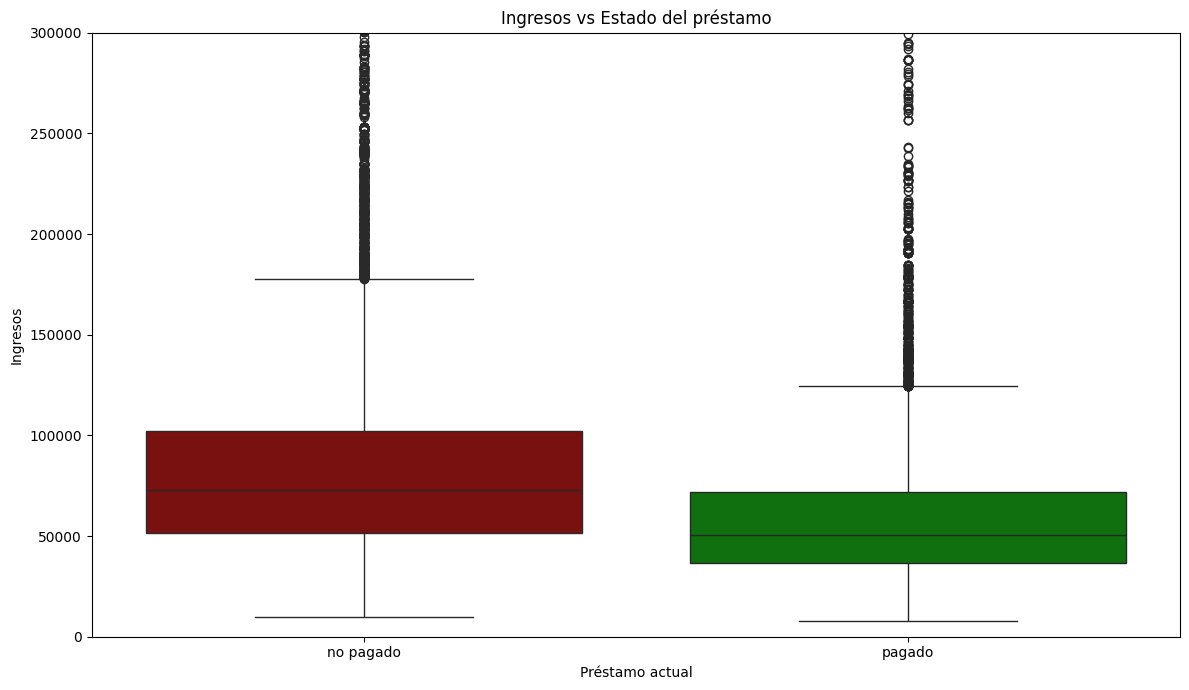

In [73]:
# Query1
query1 = """ SELECT loan_status_texto AS "Préstamo actual", person_income AS "Ingresos"
FROM loan_data
WHERE "Préstamo actual" IN ("no pagado")  """

# Query2
query2 = """ SELECT loan_status_texto AS "Préstamo actual", person_income AS "Ingresos"
FROM loan_data
WHERE "Préstamo actual" IN ("pagado") """

df1 = pd.read_sql_query(query1, conn)
df2 = pd.read_sql_query(query2, conn)

plt.figure(figsize = (12,7))

# Primer gráfico
sns.boxplot(x = "Préstamo actual", y = "Ingresos", data = df1, color = "darkred")

# Segundo gráfico
sns.boxplot(x = "Préstamo actual", y = "Ingresos", data = df2, color = "green")

plt.title("Ingresos vs Estado del préstamo")
plt.ylim(0, 300000)
plt.tight_layout()
plt.show()

---

## Observaciones visuales

El grupo de clientes que incumplió el **préstamo actual** presenta:

- una mediana de ingresos superior
- mayor dispersión en los valores
- una cantidad considerable de valores atípicos de ingresos altos

<br>

---

## Conclusión preliminar

Los **clientes incumplidores** parecen concentrar **ingresos** medios **superiores**.

Otros posibles factores:
- Montos de préstamo más elevados
- Mayor exposición financiera
- Historial crediticio

<br>

---

---

## **Proporción préstamo / ingresos vs Estado del préstamo actual**

---

#### Esta métrica permite estimar qué tan comprometidos se encuentran los ingresos del solicitante respecto del préstamo otorgado.

---

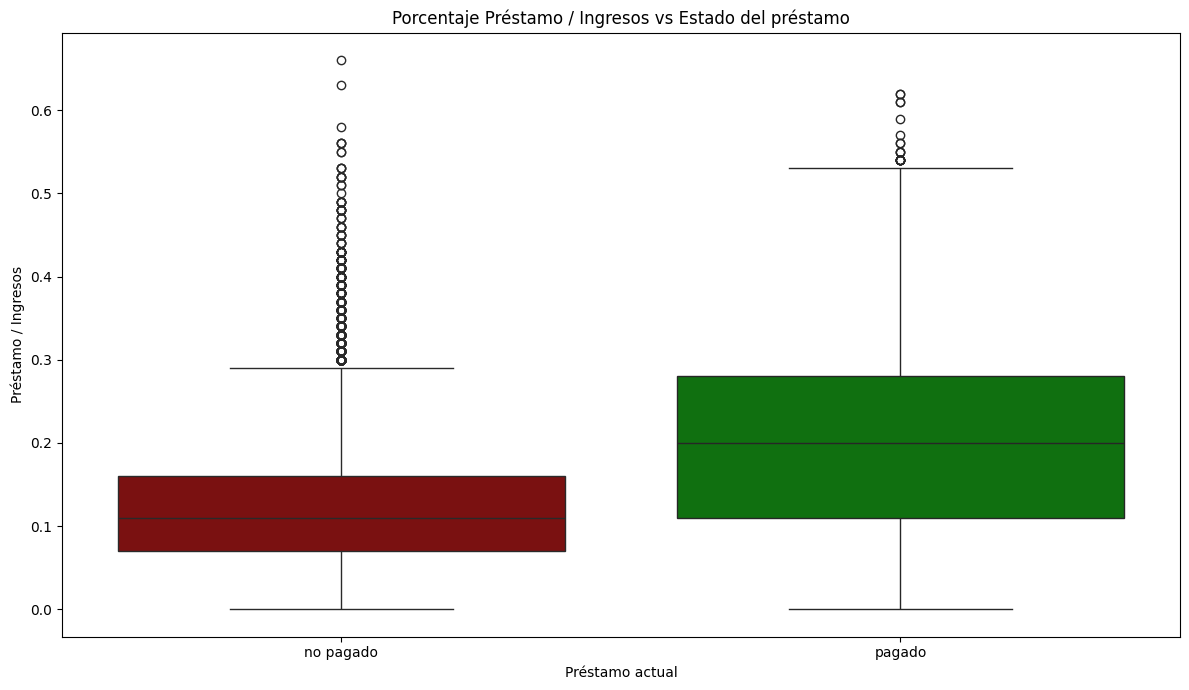

In [74]:
# Query1
query1 = """ SELECT loan_status_texto AS "Préstamo actual", loan_percent_income AS "Préstamo / Ingresos"
FROM loan_data
WHERE "Préstamo actual" IN ("no pagado")  """

# Query2
query2 = """ SELECT loan_status_texto AS "Préstamo actual", loan_percent_income AS "Préstamo / Ingresos"
FROM loan_data
WHERE "Préstamo actual" IN ("pagado") """

df1 = pd.read_sql_query(query1, conn)
df2 = pd.read_sql_query(query2, conn)

plt.figure(figsize = (12,7))

# Primer gráfico
sns.boxplot(x = "Préstamo actual", y = "Préstamo / Ingresos", data = df1, color = "darkred")

# Segundo gráfico
sns.boxplot(x = "Préstamo actual", y = "Préstamo / Ingresos", data = df2, color = "green")

plt.title("Porcentaje Préstamo / Ingresos vs Estado del préstamo")
plt.tight_layout()
plt.show()


---

## Observaciones visuales

Diferencias claras entre ambos grupos:

- Los clientes que **pagaron** correctamente, presentan una mediana **más alta** en la relación préstamo/ingresos.
- Los clientes **incumplidores** poseen ratios relativamente **menores y más concentrados**.

Además:
- El grupo de clientes **cumplidores** presenta mayor dispersión.

---

## Conclusión preliminar

Los clientes que **pagaron correctamente** parecen asumir **préstamos proporcionalmente más altos** respecto a sus ingresos.

Al mismo tiempo, los clientes **incumplidores** muestran:
- Ingresos medianos más elevados
- Menores ratios **préstamo/ingresos**

Esto podría sugerir que:
- El nivel absoluto de ingresos no garantiza un menor riesgo crediticio
- Otras variables, como el historial crediticio o el score financiero, podrían tener mayor capacidad explicativa

---

---

## **Situación habitacional TOTAL y NO cumplidores**

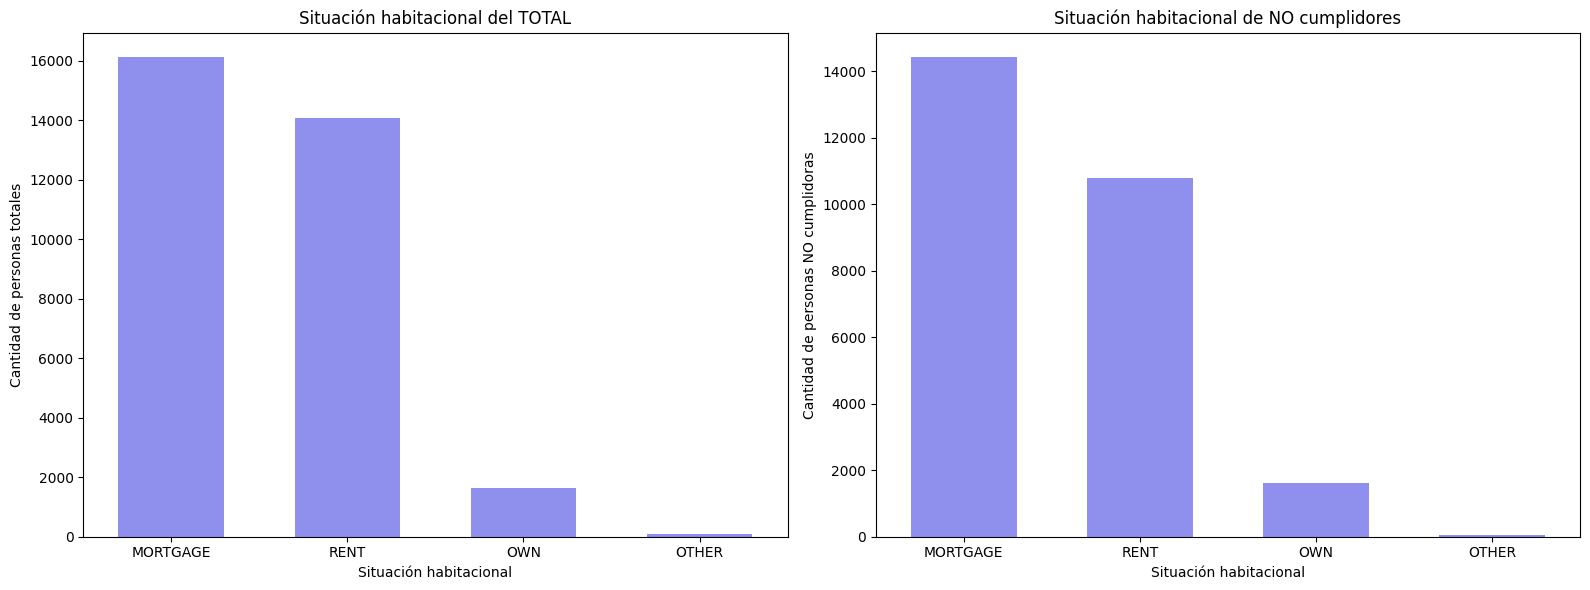

In [75]:
# Query1
query1 = """ SELECT person_home_ownership, COUNT(person_home_ownership) AS "Cantidad total"
FROM loan_data
WHERE person_income > 50000
GROUP BY person_home_ownership
ORDER BY "Cantidad total" DESC """

# Query2
query2 = """ SELECT person_home_ownership, COUNT(person_home_ownership) AS Cantidad
FROM loan_data
WHERE person_income > 50000 AND loan_status = 0
GROUP BY person_home_ownership
ORDER BY Cantidad DESC """

df1 = pd.read_sql_query(query1, conn)
df2 = pd.read_sql_query(query2, conn)

fig, axes = plt.subplots(1, 2, figsize = (16,6))

# Primer gráfico
sns.barplot(data = df1, x = "person_home_ownership", y = "Cantidad total", alpha = 0.5, color = "blue", width = 0.6, ax = axes[0])

axes[0].set_title("Situación habitacional del TOTAL")
axes[0].set_xlabel("Situación habitacional")
axes[0].set_ylabel("Cantidad de personas totales")


# Segundo gráfico
sns.barplot(data = df2, x = "person_home_ownership", y = "Cantidad", alpha = 0.5, color = "blue", width = 0.6, ax = axes[1])

axes[1].set_title("Situación habitacional de NO cumplidores")
axes[1].set_xlabel("Situación habitacional")
axes[1].set_ylabel("Cantidad de personas NO cumplidoras")

plt.tight_layout()
plt.show()

In [76]:
proporcion_M = df2.iloc[0]['Cantidad'] / df1.iloc[0]['Cantidad total']
proporcion_O = df2.iloc[2]['Cantidad'] / df1.iloc[2]['Cantidad total']

print(f"Proporción de personas con hipoteca que incumplieron: {proporcion_M * 100:.2f}%")
print(f"Proporción de personas con propiedad que incumplieron: {proporcion_O * 100:.2f}%")

Proporción de personas con hipoteca que incumplieron: 89.45%
Proporción de personas con propiedad que incumplieron: 98.36%


In [83]:
query1 = """
SELECT total.person_home_ownership, total.total_personas, no_cumplen.cantidad_NO_cumplen
FROM(SELECT person_home_ownership, COUNT(*) AS total_personas
FROM loan_data
WHERE person_income > 50000
GROUP BY person_home_ownership) total 
JOIN(SELECT person_home_ownership, COUNT(*) AS cantidad_NO_cumplen
FROM loan_data
WHERE loan_status = 0 AND person_income > 50000
GROUP BY person_home_ownership) no_cumplen
ON total.person_home_ownership = no_cumplen.person_home_ownership
ORDER BY cantidad_NO_cumplen DESC """

df1 = pd.read_sql_query(query1, conn)

print(df1)
print("\n")
for i in range(0, 4):
    print(f"{df1.iloc[i]["person_home_ownership"]}", ": ", f"{df1.iloc[i]["cantidad_NO_cumplen"] / df1.iloc[i]["total_personas"] * 100:.2f}%")
print("\n")

# Porcentaje de incumplidores sobre el total de clientes
# Query1
query2 = """ SELECT COUNT(loan_status) AS Incumplidores
FROM loan_data
WHERE loan_status = 0 """

# Query2
query3 = """ SELECT COUNT(loan_status) AS Total
FROM loan_data """

df2 = pd.read_sql(query2, conn)
df3 = pd.read_sql(query3, conn)


print(f"El {df2.iloc[0]["Incumplidores"] / df3.iloc[0]["Total"] * 100:.2f}% del TOTAL de clientes incumplió con el préstamo actual.")

  person_home_ownership  total_personas  cantidad_NO_cumplen
0              MORTGAGE           16129                14427
1                  RENT           14085                10789
2                   OWN            1650                 1623
3                 OTHER              89                   66


MORTGAGE :  89.45%
RENT :  76.60%
OWN :  98.36%
OTHER :  74.16%


El 77.78% del TOTAL de clientes incumplió con el préstamo actual.


---

---

## Observaciones

- La categoría **alquiler** es más numerosa en el **total de clientes**. Aun así, los clientes **hipotecados** lideran la sección de **incumplimiento** en cantidades absolutas
- **Propietarios** e **hipoteca** lideran ampliamente la sección de **incumplimiento relativo**

<br>

---

## Porcentaje de incumplimiento por situación habitacional

Porcentaje general de incumplimiento es:

- **77.78%**

<br>

| Situación habitacional | % de incumplimiento |
|---|---:|
| MORTGAGE | 89.45% |
| RENT | 67.09% |
| OWN | 98.36% |
| OTHER | 66.67% |

<br>

---

## Conclusión preliminar

Los resultados sugieren que la **situación habitacional** podría estar relacionada con el riesgo crediticio.

Particularmente:
- Clientes con **hipoteca**
- **Propietarios**

presentan tasas de incumplimiento superiores al promedio general.

Esto podría indicar que los clientes que ya poseen compromisos financieros importantes relacionados con la vivienda podrían enfrentar mayores niveles de presión financiera al asumir nuevas obligaciones crediticias.


---

## **Modelo de entrenamiento para prevención de incumplimientos en el pago**

---

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

query1 = """ 
SELECT loan_status, credit_score, loan_percent_income, loan_int_rate, previous_loan_defaults_on_file, person_income
FROM loan_data """

df1 = pd.read_sql_query(query1, conn)

# =========================
# Transformacion variables
# =========================

# Yes/No -> 1/0
df1["previous_loan_defaults_on_file"] = (df1["previous_loan_defaults_on_file"].map({"Yes": 1, "No": 0}))

# =========================
# Variables predictoras
# =========================

X = df1.drop("loan_status", axis = 1)

# Variable objetivo
y = df1["loan_status"]

# =========================
# Train / Test
# =========================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

# =========================
# Escalado
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# Modelo
# =========================

model = LogisticRegression()

model.fit(X_train, y_train)

# =========================
# Predicciones
# =========================

y_pred = model.predict(X_test)

# =========================
# Resultados
# =========================

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte:")
print(classification_report(y_test, y_pred))

Accuracy:
0.8799111111111111

Matriz de confusión:
[[8097  633]
 [ 718 1802]]

Reporte:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      8730
           1       0.74      0.72      0.73      2520

    accuracy                           0.88     11250
   macro avg       0.83      0.82      0.83     11250
weighted avg       0.88      0.88      0.88     11250



---
## Conclusión del modelo predictivo

El modelo identificó correctamente cerca del 72% de los futuros incumplidores, manteniendo una precisión global aproximada del 88% en las predicciones realizadas.

Variables como **historial de incumplimientos previos, score crediticio, nivel de ingresos y situación habitacional** poseen una **fuerte capacidad predictiva** de default.

Además, el análisis detectó patrones particularmente críticos:

- Los clientes con **vivienda hipotecada** e ingresos **mayores a $50.000** presentaron un incumplimiento del **89.45%**.
- Los clientes **propietarios** con ingresos **mayores a $50.000** presentaron un incumplimiento en el **98.36%** de los casos.

Los resultados evidencian que el **riesgo crediticio** depende **principalmente** de la combinación entre **historial financiero, nivel de endeudamiento y situación habitacional**.

<br>

---

<br>

---

## **Conclusiones finales**

- Establecer revisiones manuales obligatorias para clientes con perfil `OWN` y `MORTGAGE`, debido a tasas de incumplimiento superiores al **88%**.

- Priorizar el historial de **incumplimientos previos** como criterio central de aprobación, ya que fue una de las variables con **mayor** capacidad predictiva del modelo.

- Incorporar el modelo predictivo como filtro previo de riesgo para reducir aprobaciones de clientes con alta probabilidad de default.

- Implementar políticas de scoring combinando:
  - historial crediticio,
  - score financiero,
  - situación habitacional,
  - relación préstamo/ingreso.

Esto permitiría detectar perfiles de alto riesgo antes de otorgar el préstamo y reducir potenciales pérdidas por incumplimiento.

In [89]:
# Query1
query1 = """ SELECT COUNT(loan_status) AS "Total de prestamos"
FROM loan_data 
WHERE loan_status = 0"""

# Query2
query2 = """ SELECT AVG(loan_amnt) AS "Monto promedio de préstamo"
FROM loan_data """

df1 = pd.read_sql_query(query1, conn)
df2 = pd.read_sql_query(query2, conn)

print(f"El total de préstamos incumplidos: {df1.iloc[0]['Total de prestamos']}")
print(f"El monto promedio de préstamo es: ${df2.iloc[0]['Monto promedio de préstamo']:.2f}")

El total de préstamos incumplidos: 35000
El monto promedio de préstamo es: $9583.16


---

### **Impacto para el negocio**

- El total de préstamos **incumplidos** fue de aproximadamente **35.000 operaciones**.
- El modelo logró detectar cerca del **72%** de esos casos, identificando preventivamente alrededor de **25.200 préstamos de alto riesgo**.
- Considerando un monto promedio de préstamo de **$9.583,16**, la implementación del modelo podría evitar pérdidas potenciales cercanas a:

# **$241.495.632**

---
<br>

---

#### **Aclariación adicional**: Algunos análisis segmentados por edad, historial crediticio y motivo del préstamo fueron descartados del informe final debido a la baja cantidad de observaciones en ciertos grupos, lo que generaba alta volatilidad y reducía la confiabilidad estadística de las conclusiones